---
## Overview
PyChrono is a port of Chrono, which is coded in C++, for Python. The module is a very versatile tool that allows you to simulate 3D bodies of differing properties while tracking nearly any kinematic quantity needed for model simulations.

In this document I will be using PyChrono to simulate a 3D pendulum on a ball joint, with a variable length and angular displacement, to see how it would oscilate in 3D space. This could be expanded to find out information reguarding simple harmonic oscillators, drag, collisions, and much more.

---
## Installation:

The installation of PyChrono into Jupyter notebook is slightly non-trivial, so I have made a guide as to how I was able to import the module onto my personal JupyterHub. There may be other, more efficient ways to do this however.

Firstly, open the terminal in your home directory. Then enter the correct package location, which in this case is mamba, using:

>mamba activate
    
The terminal may give an error. If this is the case, follow the instructions given until you are able to successfully run the command. Once completed, you will see a set of parenthesis infront of your ternimal location indicating you are in (base).

Next, we want to install the PyChrono library from anaconda forge. If a [Y/N] confirm prompt appears, enter Y:

>mamba create -n chrono python=3.12

>mamba activate chrono

>mamba install projectchrono::pychrono - c conda-forge

Now that PyChrono is installed, you will need to initialize an accessable kernel in JupyterHub so that you can make a notebook that can use the chrono directory. If you are no longer within the (chrono) terminal, run:

>mamba activate chrono

Then, once in (chrono): 

>mamba install ipykernel

>mamba install matplotlib

>python -m ipykernel install --user --name chrono --display-name "Python (chrono)"

Now, when you open a notebook, you can select the new Python (chrono) kernel and run the library by using:
```python
import pychrono as (nickname)
```
---

## Notes:

One major feature of PyChrono is its seamless integration with irrlicht, which allows code to be visualized. Unfortunately, this visualization requires OpenGL (and a graphics card) to run, which as far as I can tell, our university does not provide for JupyterHub. This means that we can only use their physics models to simulate things without direct visuals. This is still incredibly useful, however, if you want to use the visualization of PyChrono, you will have to run the code on your individual computer since OpenGL can be opened by your device. 

`WARNING` if you attempt to visualize a simulation in your unmodified Jupyter Notebook, it will kill the kernel as there is no location to render the code

---

In [2]:
import pychrono as chro
import numpy as np
import matplotlib.pyplot as plt

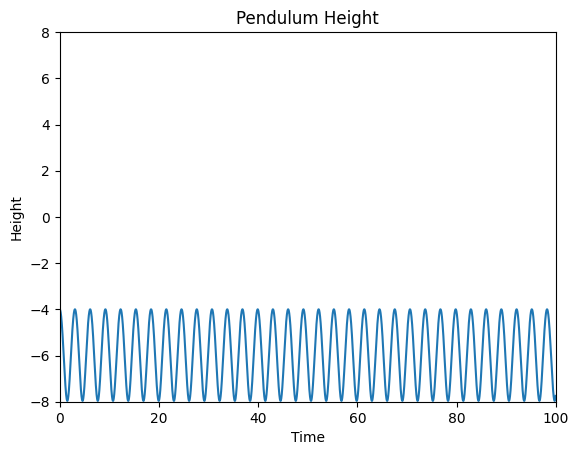

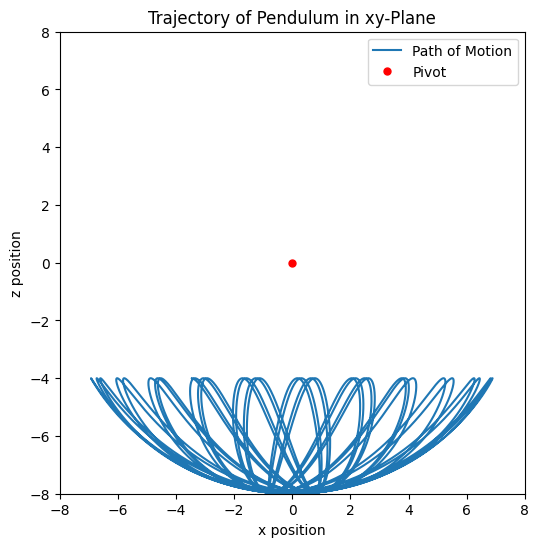

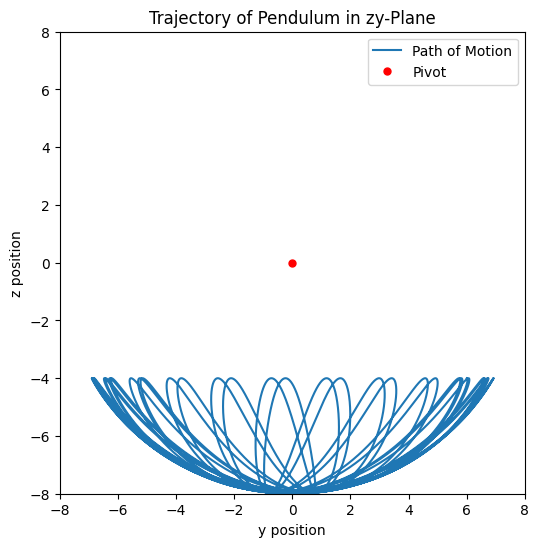

In [28]:
length = 8
theta = 8*np.pi/12
phi = 8*np.pi/12
angular_velocity = 1

#plotly

tf = 100
N = 10000

sys = chro.ChSystemNSC()
sys.SetGravityZ()

initial_velocity = chro.ChVector3d(angular_velocity*np.sin(theta),-angular_velocity*np.cos(theta),0)

#Creating fixed rigid position
ground = chro.ChBody()
ground.SetFixed(True)
ground.SetPos(chro.ChVector3d(0,0,0))
sys.Add(ground)

#Creating swinging rigid body
pendulum = chro.ChBody()
pendulum.SetFixed(False)
pendulum.SetPos(chro.ChVector3d(length*np.sin(phi)*np.cos(theta), length*np.sin(phi)*np.sin(theta), length*np.cos(phi)))
pendulum.SetLinVel(initial_velocity)
sys.Add(pendulum)

#Create a spherical link
link = chro.ChLinkLockSpherical()

#Setting position of pivot
pivot = chro.ChFramed(chro.ChVector3d(0,0,0))

#Connecting parts together
link.Initialize(ground,pendulum, pivot)

sys.Add(link)

#Setting arrays and constants for loop
plt.close()
time = np.zeros(N)
x_pos = np.zeros(N)
y_pos = np.zeros(N)
z_pos = np.zeros(N)

dt = tf/N
t=0

for i in range(N):
    
    sys.DoStepDynamics(dt)
    pos = pendulum.GetPos()

    time[i] = t
    x_pos[i] = pos.x
    y_pos[i] = pos.y
    z_pos[i] = pos.z

    t += dt

#Plotting data
fig_z, ax_z = plt.subplots()
ax_z.plot(time, z_pos)
ax_z.set_xlim(0,tf)
ax_z.set_ylim(-length,length)
ax_z.set( 
    xlabel='Time',
    ylabel='Height',
    title='Pendulum Height'
)

fig_xz, ax_xz = plt.subplots(figsize=(6,6))
ax_xz.plot(x_pos, z_pos, label='Path of Motion')
ax_xz.plot(0, 0, 'ro', markersize=5, label='Pivot')
ax_xz.set_xlim(-length,length)
ax_xz.set_ylim(-length,length)
ax_xz.legend()
ax_xz.set( 
    xlabel='x position',
    ylabel='z position',
    title='Trajectory of Pendulum in xy-Plane',
)

fig_yz, ax_yz = plt.subplots(figsize=(6,6))
ax_yz.plot(y_pos, z_pos, label='Path of Motion')
ax_yz.plot(0, 0, 'ro', markersize=5, label='Pivot')
ax_yz.set_xlim(-length,length)
ax_yz.set_ylim(-length,length)
ax_yz.legend()
ax_yz.set( 
    xlabel='y position',
    ylabel='z position',
    title='Trajectory of Pendulum in zy-Plane'
)
plt.show();

---
I first worked with a 2D pendulum, however, I felt it would be very interesting to convert the cartesian basis into a spherical one, and use spherical joints to allow a range of motion that can be effected by the phi and theta that you set the pendulum object to, the length of the pendulum mass from the spherical joint, and what initial tangential velocity the pendulum had. 

Since i can not use the visualization capabilities of PyChrono, I decided to iterate the pendulum over a certain number of steps, and record the position values of the simulated pendulum and project them in the xz and yz planes (as z is the vertical axis). Adding how z changes over time, and the code gives a decent visual representation of that it happening to the pendulum in 3D space.

This project, and how PyChrono works, gave me a very satisfying result that is fun to wrap your head around and play with by changing the period and complex motion of the pendulum through tweaking the initial conditions.

---
I learned the basic properties of the PyChrono library through multiple tutorials and forums provided by the Project Chrono website.
https://api.projectchrono.org/development/pychrono_introduction.html

---